# Projet de MLOps 

### Objectif

L'équipe de risque analyse le portefeuille de prêts existants pour prévoir les défauts potentiels futurs et estimer la perte attendue. L'objectif principal est de construire un modèle prédictif qui estime la probabilité de défaut pour chaque client en fonction de ses caractéristiques. Des prédictions précises permettront à la banque d'allouer sufisamment de capital pour couvrir les pertes potentielles maintenant ainsi la stabilité financieres.

## 1. Setup et Exploration (EDA)

L'Analyse Exploratoire des Données (EDA) est la première étape concrète de l'analyse après le setup du projet et elle est cruciale pour le succès de notre modèle de risque de crédit. Elle fait partie de l'étape de Pré-traitement des données

### A. Chargement des Données

Charger le jeu de données

In [ ]:
#Librairies de manipulation de données
import pandas as pd # type: ignore
import numpy as np # type: ignore

#Librairies de visualisation
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore

#Librairies de Machine Learning et MLOps
import sklearn  # type: ignore
import mlflow # type: ignore

In [3]:
df = pd.read_csv('Loan_Data.csv')

In [6]:
pd.read_csv('Loan_Data.csv')

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [5]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [8]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


Variation d'Échelle : L'income (≈70000 en moyenne) et le fico_score (≈637) sont sur des échelles très différentes ce qui rend l'étape de mise à l'échelle (scaling) absolument nécessaire avant d'utiliser la Régression Logistique ou d'autres modèles sensibles aux échelles.

### b. Compréhension et Analyse de la Variable Cible (y)

Le cœur de ce projet est de prévoir le défaut de paiement

Taux de Défaut Crucial : La moyenne de la variable default est de 0.1851. Cela signifie que le taux de défaut est de 18.51%. C'est un taux significatif qui confirme que nous devons utiliser des métriques robustes comme l'AUC-ROC ou le F1-Score

In [9]:
#Taux de défaut de paiement
taux_defaut = df['default'].mean() * 100
print(f"\nTaux de défaut de paiement: {taux_defaut:.2f}%")


Taux de défaut de paiement: 18.51%


on identifie la Cible et on localise la colonne binaire qui indique si le prêt a fait l'objet d'un défaut est codé 1 si il est rembouser il sera codé 0.

Dans le secteur bancaire, les défauts sont généralement rares (souvent moins de 5%). Un fort déséquilibre influence le choix des métriques (privilégier l'AUC-ROC ou le F1-Score au lieu de l'exactitude simple) et peut nécessiter des techniques de rééchantillonnage (oversampling/undersampling) lors de la modélisation.

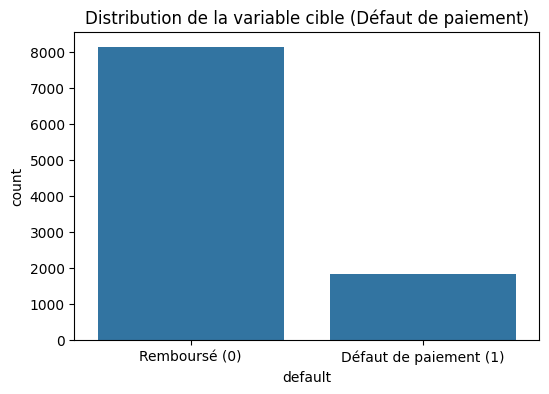

In [10]:
#Visualisation de la distribution de la variable cible
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df)
plt.title('Distribution de la variable cible (Défaut de paiement)')
plt.xticks([0, 1], ['Remboursé (0)', 'Défaut de paiement (1)'])
plt.show()

Clients remboursés (0) : Le graphique montre environ 8000 cas (la grande majorité).

Défauts de paiement (1) : Le graphique montre environ 1851 cas (basé sur la moyenne de 0.1851 précédemment fournie correspondant à la barre à un peu moins de 2000).

Ce déséquilibre a des implications directes sur la manière d'évaluer nos modèles

* AUC-ROC (Area Under the Receiver Operating Characteristic Curve) : La métrique la plus courante pour le risque de crédit. Elle mesure la capacité du modèle à classer correctement les défauts sur toute la plage de seuils.

* Recall (Rappel) : Mesure la proportion de défauts réels que votre modèle a correctement identifiés (vrais positifs / (vrais positifs + faux négatifs)). Essentiel pour la banque afin de ne pas manquer de mauvais payeurs.

* F1-Score : La moyenne harmonique de la précision (Precision) et du rappel (Recall).

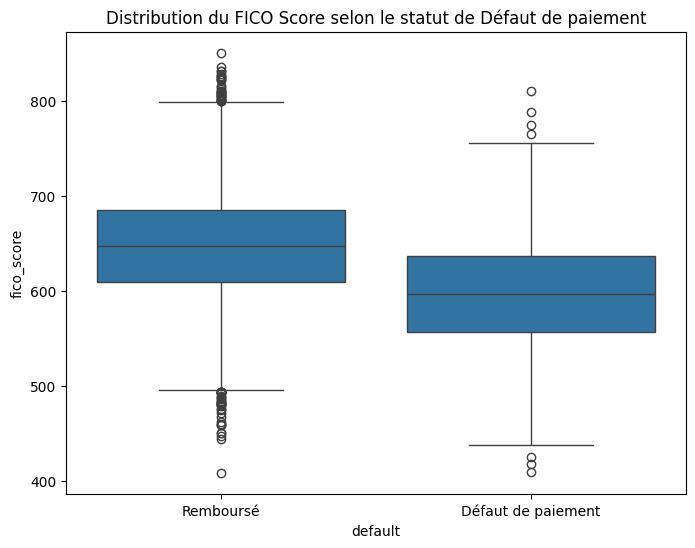

In [11]:
#Relation entre FICO Score et Défaut de paiement
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='fico_score', data=df)
plt.title('Distribution du FICO Score selon le statut de Défaut de paiement')
plt.xticks([0, 1], ['Remboursé', 'Défaut de paiement'])
plt.show()

Le graphique montre que la Distribution du FICO Score selon le statut de Défaut de paiement confirme une relation fondamentale dans le risque de crédit :
* Remboursé (0) : Les clients qui ont remboursé leur prêt ont des scores FICO significativement plus élevés (autour de 650-660).
* Défaut de paiement (1) : Les clients en défaut de paiement ont des scores FICO plus bas (autour de 600).

Conclusion : La variable fico_score est un excellent prédicteur de la variable cible (default).

La Matrice de Corrélation est essentielle pour comprendre la relation de chaque variable avec la cible (default) et les relations entre les autres variables.

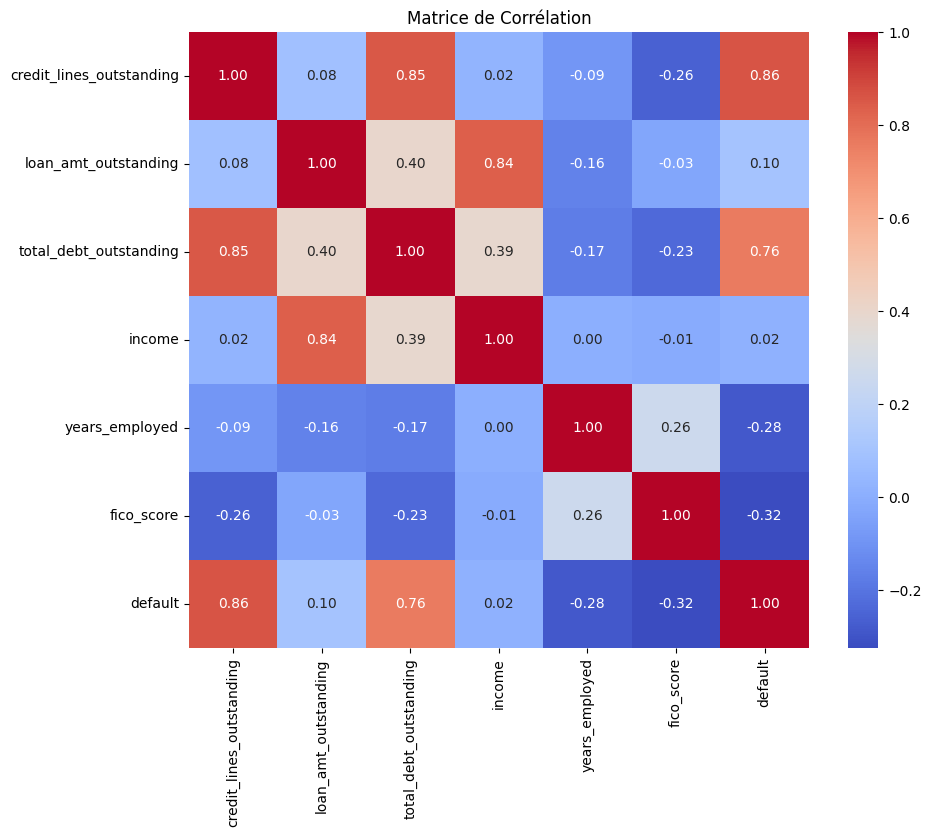

In [12]:
#Matrice de corrélation
correlation_matrix = df.drop(columns=['customer_id']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation')
plt.show()

## 2. Pré-traitement et Feature Engineering

Cette étape finalise la préparation des données pour les modèles.

### A. Gestion des Valeurs Manquantes

Les données incomplètes peuvent fausser les modèles

In [13]:
print(df.isnull().sum())

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64


Puisqu'on a pas de valeurs manquantes ni de variables catégorielles à encoder on se concentre sur le feature engineering

### B. Feature Engineering

Après l'EDA, on crée une variable qui sera la plus prédictive : le ratio Dette/Revenu.

In [ ]:
import pandas as pd # type: ignore
import numpy as np # type: ignore

In [ ]:
#Création du Ratio Dette / Revenu (Debt-Income variable)
#C'est total_debt_outstanding / income
df['debt_income_variable'] = np.where(
    #SSi l'income est 0 on met une valeur élevée pour le risque
    df['income'] == 0,
    df['total_debt_outstanding'], 
    df['total_debt_outstanding'] / df['income']
)
print("Nouvelle feature 'debt_income_variable' a été créé.")

Nouvelle feature 'debt_income_variable' a été créé.


In [15]:
df.columns

Index(['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default', 'debt_income_variable'],
      dtype='object')

## 3. Séparation des données et la Mise à l'échelle (Scaling)

### A. Séparation des Données (Train/Test Split)

Nous séparons les données d'entraînement (80%) des données de test (20%). Le paramètre stratify=y est obligatoire pour garantir que le taux de défaut de 18.51% est conservé dans les deux ensembles donc il faut séparer les données en ensembles d'entraînement et appliquer le StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
import pandas as pd  # type: ignore

In [ ]:
X = df.drop([
    'customer_id', 
    'default', 
    'total_debt_outstanding',       
    'loan_amt_outstanding',         
    'credit_lines_outstanding'      
], axis=1) 
y = df['default']

In [35]:
#Séparation des jeux de données Entraînement/Test (80/20)
#stratify=y est nécessaire car nous avons un déséquilibre (18.51% de défauts)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### B. Mise à l'Échelle (Scaling) avec StandardScaler

In [36]:
#Mise à l'Échelle (Scaling)
scaler = StandardScaler()

In [37]:
#1. Entraîner le scaler UNIQUEMENT sur l'ensemble d'entraînement
X_train_scaled = scaler.fit_transform(X_train)

#2. Appliquer le scaler sur l'ensemble de test
X_test_scaled = scaler.transform(X_test)


In [ ]:
#Reconversion en DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\ndonnées séparées et scaled dans X_train_scaled et X_test_scaled.")


Données séparées et mises à l'échelle (scaled) dans X_train_scaled et X_test_scaled.


## 4. Model Engineering et Tracking MLflow

Cette étape prépare l'environnement technique pour le Model Engineering et de MLflow

### A. Model Engineering

In [ ]:
import mlflow # type: ignore
from sklearn.linear_model import LogisticRegression # type: ignore
from sklearn.tree import DecisionTreeClassifier # type: ignore
from sklearn.ensemble import RandomForestClassifier # type: ignore
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score # type: ignore

In [40]:
#on crée un dossier 'mlruns' pour stocker les résultats de MLflow
mlflow.set_tracking_uri("file:./mlruns") 

In [41]:
#Fonction d'évaluation utilisable pour tous les modèles
def evaluate_model(model, X_test, y_test):
    # Probabilités pour le calcul de l'AUC-ROC
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    # Prédictions binaires
    y_pred = model.predict(X_test)
    
    #Calcul des métriques
    metrics = {
        "AUC-ROC": roc_auc_score(y_test, y_pred_proba),
        "F1_Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    }
    return metrics

### B. Tracking MLflow

#### Modèle 1 : Régression Logistique

In [ ]:
import mlflow # type: ignore
from sklearn.linear_model import LogisticRegression # type: ignore

In [ ]:
#Un modèle → un experiment
mlflow.set_experiment("1_Logistic_Regression_Risk_Model") 
#Hyperparamètres
params_logreg = {"C": 0.1, "solver": "liblinear", "random_state": 42}
with mlflow.start_run(run_name="LogReg_Run_1_C0.1"): 
    mlflow.log_params(params_logreg)
    log_reg = LogisticRegression(**params_logreg)
    log_reg.fit(X_train_scaled, y_train)
    
    #Évaluation et enregistrement des métriques et du modèle
    metrics_logreg = evaluate_model(log_reg, X_test_scaled, y_test)
    mlflow.log_metrics(metrics_logreg)
    mlflow.sklearn.log_model(log_reg, "logistic_model")
    
    print(f"Modèle 1: AUC-ROC: {metrics_logreg['AUC-ROC']:.4f}")

2025/10/12 01:33:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/12 01:34:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle 1: AUC-ROC: 0.9989


#### Modèle 2 : Decision Tree

In [ ]:
import mlflow # type: ignore
from sklearn.tree import DecisionTreeClassifier # type: ignore

In [ ]:
#Un modèle → un experiment
#apres avoir défini X_train_scaled, X_test_scaled, y_train, y_test et la fonction evaluate_model

mlflow.set_experiment("2_Decision_Tree_Risk_Model") 

params_dt = {"max_depth": 5, "min_samples_leaf": 20, "random_state": 42}

with mlflow.start_run(run_name="DT_Run_1_Depth5"): 
    mlflow.log_params(params_dt)
    
    dt_clf = DecisionTreeClassifier(**params_dt)
    dt_clf.fit(X_train_scaled, y_train) 
    
    metrics_dt = evaluate_model(dt_clf, X_test_scaled, y_test)
    mlflow.log_metrics(metrics_dt)
    mlflow.sklearn.log_model(dt_clf, "decision_tree_model")
    
    print(f"Modèle 2 : AUC-ROC: {metrics_dt['AUC-ROC']:.4f}")

2025/10/12 01:39:40 INFO mlflow.tracking.fluent: Experiment with name '2_Decision_Tree_Risk_Model' does not exist. Creating a new experiment.
2025/10/12 01:39:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/12 01:39:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle 2 tracké. AUC-ROC: 0.9951


#### Modèle 3 : Random Forest

In [ ]:
import mlflow # type: ignore
from sklearn.ensemble import RandomForestClassifier # type: ignore

In [ ]:
#Un modèle → un experiment
mlflow.set_experiment("3_Random_Forest_Risk_Model") 

params_rf = {"n_estimators": 200, "max_depth": 8, "random_state": 42}

with mlflow.start_run(run_name="RF_Run_1_N200_D8"): 
    mlflow.log_params(params_rf)
    
    rf_clf = RandomForestClassifier(**params_rf)
    rf_clf.fit(X_train_scaled, y_train)
    
    metrics_rf = evaluate_model(rf_clf, X_test_scaled, y_test)
    mlflow.log_metrics(metrics_rf)
    mlflow.sklearn.log_model(rf_clf, "random_forest_model")
    
    print(f"Modèle 3 : AUC-ROC: {metrics_rf['AUC-ROC']:.4f}")

2025/10/12 01:43:31 INFO mlflow.tracking.fluent: Experiment with name '3_Random_Forest_Risk_Model' does not exist. Creating a new experiment.
2025/10/12 01:43:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/12 01:43:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Modèle 3 : AUC-ROC: 0.9988


En se basant uniquement sur la métrique AUC-ROC (la métrique standard pour évaluer l'efficacité des modèles de risque de crédit) :

* Le modèle le plus performant est la Régression Logistique avec 0.9989.

* Le Random Forest suit de très près avec 0.9988.

Une fois que le troisième modèle aura fini de s'exécuter, on a trois experiments dans MLflow.

Lancez MLflow UI : Ouvrez le terminal, ecrire : mlflow ui et exécutez :running on http://127.0.0.1:5000 

## 5. Le Déploiement de l'application

le Déploiement de votre meilleur modèle (la Régression Logistique) sur une application web via un pipeline CI/CD conformément aux exigences du projet.

### A. Création de l'Application Web avec streamlit

voir fichier main_app.py

### B. Pipeline CI/CD

L'étape finale sera la mise en place d'un pipeline pour :